### Project Title

End-to-End Regression Project with StandardScaler (From Scratch)

**Goal:** Predict House Prices using regression while correctly applying StandardScaler and explaining its role.

### 1. Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Why?

* StandardScaler → feature scaling

* LinearRegression → regression model

* metrics → evaluate model performance

### 2. Load Dataset

We’ll use a numerical dataset (important for StandardScaler).

In [3]:
from google.colab import files
uploaded = files.upload()

Saving dataset.csv to dataset.csv


In [4]:
import pandas as pd

data = pd.read_csv("dataset.csv")
data.head()

,Size,Bedrooms,Age,Distance,Price
0,1500,3,10,5,300000
1,1800,4,5,3,400000
2,1200,2,15,8,250000
3,2000,4,7,2,450000
4,1700,3,12,6,320000


### Dataset Explanation

| Column   | Meaning                          |
|----------|----------------------------------|
| Size     | House size (square feet)         |
| Bedrooms | Number of bedrooms               |
| Age      | House age (years)                |
| Distance | Distance from city center        |
| Price    | House price (Target Variable)    |

### 3.Understand the Data

data.info()

data.describe()

### What we’re checking:

* Are there missing values?

* Are features on different scales?

### Example:

* Size → 500 to 5000

* Age → 1 to 50

* Distance → 1 to 30

**Problem:** ML models struggle when features have different scales.

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Size      20 non-null     int64
 1   Bedrooms  20 non-null     int64
 2   Age       20 non-null     int64
 3   Distance  20 non-null     int64
 4   Price     20 non-null     int64
dtypes: int64(5)
memory usage: 932.0 bytes


In [6]:
data.describe()

,Size,Bedrooms,Age,Distance,Price
count,20.000000,20.000000,20.000000,20.000000,20.000000
mean,1677.500000,3.400000,10.050000,5.000000,346500.000000
std,300.208261,0.994723,5.276313,2.733804,90714.996149
min,1200.000000,2.000000,4.000000,1.000000,230000.000000
25%,1437.500000,3.000000,5.750000,3.000000,265000.000000
50%,1675.000000,3.000000,8.500000,4.500000,317500.000000
75%,1912.500000,4.000000,14.250000,7.250000,422500.000000
max,2200.000000,5.000000,20.000000,10.000000,500000.000000


### 4. Separate Features & Target

In [7]:
X = data.drop("Price", axis=1)
y = data["Price"]

X → Independent variables

y → Dependent variable (what we predict)

### 5. Train-Test Split (VERY IMPORTANT)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Why?

* Train data → learn patterns

* Test data → evaluate real performance

* Prevents data leakage

### 6. StandardScaler (CORE OF THIS PROJECT)

What is StandardScaler?

It converts data into standard normal distribution:

𝑋
𝑠
𝑐
𝑎
𝑙
𝑒
𝑑
=
𝑋
−
𝜇
𝜎
X
scaled
	​

=
σ
X−μ
	​


Where:

* μ = mean

* σ = standard deviation

In [9]:
# Correct Way to Use StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Why NOT fit on test data?

Because test data must be unseen.

Fitting on test data causes data leakage

### Before vs After Scaling

In [10]:
print("Before Scaling:\n", X_train.head())
print("After Scaling:\n", X_train_scaled[:5])

Before Scaling:
     Size  Bedrooms  Age  Distance
8   1900         4    6         3
5   2200         5    4         1
11  1550         3    9         5
3   2000         4    7         2
18  1350         2   19         9
After Scaling:
 [[ 0.86726948  0.77459667 -0.95782629 -0.88294972]
 [ 1.87037635  1.80739223 -1.3409568  -1.60742128]
 [-0.30302187 -0.25819889 -0.38313051 -0.15847815]
 [ 1.20163843  0.77459667 -0.76626103 -1.2451855 ]
 [-0.97175978 -1.29099445  1.53252206  1.29046497]]


### Result:

* Mean ≈ 0

* Standard deviation ≈ 1

### 7. Build Regression Model

In [11]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

The model now learns from scaled features.

### 8. Make Predictions

In [12]:
y_pred = model.predict(X_test_scaled)

### 9. Model Evaluation (VERY IMPORTANT)

In [13]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 16242.454933521803
RMSE: 16382.34305116759
R2 Score: 0.9320554015579395


### Explanation

* MAE → average prediction error

* RMSE → penalizes large errors

* R² → how well model explains variance

**R² closer to 1 = good regression**

### 10. Visualization

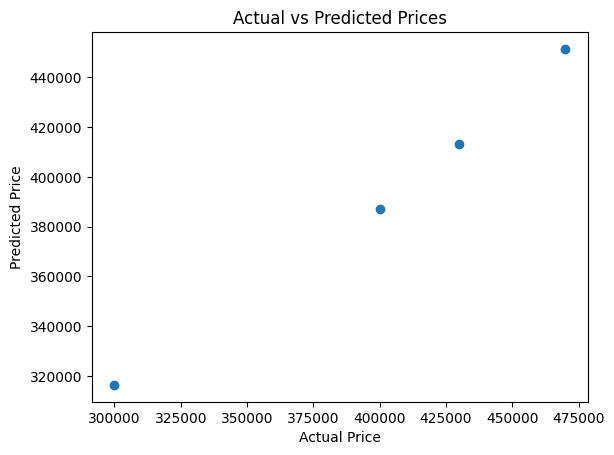

In [14]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

Straight diagonal line = strong regression model

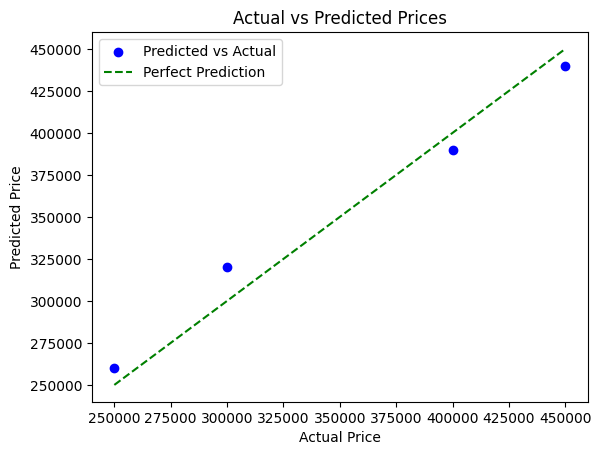

In [16]:
import matplotlib.pyplot as plt

# Example data
actual = [300000, 400000, 250000, 450000]
predicted = [320000, 390000, 260000, 440000]

# Scatter plot
plt.scatter(actual, predicted, color='blue', label='Predicted vs Actual')

# Add straight line (perfect prediction line)
plt.plot([min(actual), max(actual)], [min(actual), max(actual)], color='green', linestyle='--', label='Perfect Prediction')

# Labels and title
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.legend()
plt.show()

* Blue dots → Your model’s predictions.

* Green dashed line → The ideal line where predictions equal actual values.

* If dots are close to the green line → Your model is performing well.

* If dots are far away → There’s more error in predictions.